In [2]:
import numpy as np#다차원 배열 생성
matrix = np.array([[1,2,3],[4,5,6]])
print(f"matrix:\n{matrix}")


matrix:
[[1 2 3]
 [4 5 6]]


In [3]:
import pandas as pd

# 데이터프레임생성
data ={
    'Name':['Alice','Bob','Charlie'],
    'Age':[25,30,35],
    'City':['Newyork','LA','Chicago']
}

df = pd.DataFrame(data)
print(f"DataFrame:\n{df}")

DataFrame:
      Name  Age     City
0    Alice   25  Newyork
1      Bob   30       LA
2  Charlie   35  Chicago


In [4]:
#열선택
names =  df['Name']
print(f"Names:\n{names}")

Names:
0      Alice
1        Bob
2    Charlie
Name: Name, dtype: str


In [5]:
#조겉필터링
age_above_30 =  df[df['Age']>30]
print(f"age_above_30:\n{age_above_30}")

age_above_30:
      Name  Age     City
2  Charlie   35  Chicago


In [9]:
df['Salary']=[70000,80000,90000]
print(f"DataFrame with Salary:\n'{'Salary'}")

DataFrame with Salary:
'Salary


In [12]:
import seaborn as sns

In [13]:
# 데이터 로드
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(url)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [14]:
import pandas as pd
import ssl
import urllib.request


In [16]:
ssl._create_default_https_context = ssl._create_unverified_context
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(url)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

d:\JSH\venv\venv2\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


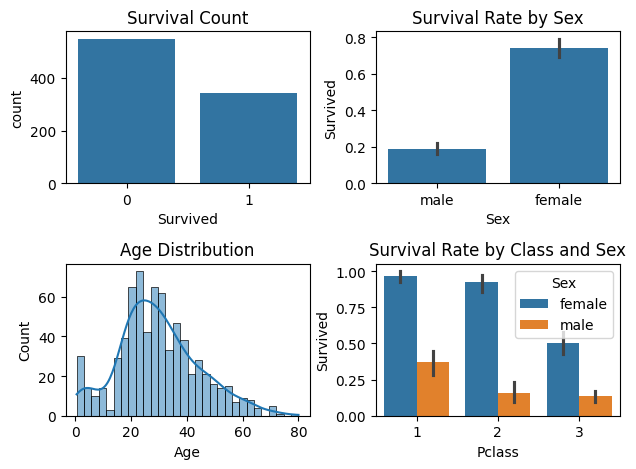

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import io

# 데이터 로드 (SSL 오류 우회)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
response = requests.get(url, verify=False)
titanic_df = pd.read_csv(io.StringIO(response.text))

# Figure와 서브플롯 생성
fig, axes = plt.subplots(2, 2)

# 생존자와 사망자 수 시각화
sns.countplot(data=titanic_df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Count')

# 성별에 따른 생존률 시각화
sns.barplot(data=titanic_df, x='Sex', y='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Sex')

# 나이 분포 시각화
sns.histplot(data=titanic_df, x='Age', bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution')

# 클래스별 생존률 시각화
sns.barplot(data=titanic_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1, 1])
axes[1, 1].set_title('Survival Rate by Class and Sex')

# 레이아웃 조정
plt.tight_layout()
plt.show()